In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex
import torch

from diffSPH.sampling import sampleRegularParticles, sampleOptimal
from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
from diffSPH.operations import GradientMode, LaplacianMode, SupportScheme
from diffSPH.enums import *
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.modules.density import computeDensity

from diffSPH.sdf import operatorDict, getSDF
from diffSPH.sphOperations.shared import scatter_sum
from matplotlib.colors import LogNorm

from waveEqn import WaveEquationState, waveEquation2
from typing import Union, Tuple
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood
from diffSPH.operations import GradientMode, LaplacianMode
from diffSPH.kernels import SPHKernel
from diffSPH.enums import *
from diffSPH.operations import SPHOperation, Operation
from diffSPH.schemes.states.common import BasicState
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr, filterNeighborhoodByKind
from diffSPH.operations import ParticleSetWithQuantity, sph_op
from diffSPH.kernels import getSPHKernelv2
from diffSPH.plotting import visualizeParticles, updatePlot, plotDistribution
from diffSPH.operations import SPHOperation, Operation
from diffSPH.util import getPeriodicPositions
from diffSPH.integrationSchemes.util import integrateQ
from diffSPH.integration import getIntegrator
import copy
from waveEqn import WaveSystem, waveSystemFunction

In [2]:
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
nx = 128

config, domain, device, dtype, kernel = generateInitialVariables(
    nx, device = device
)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

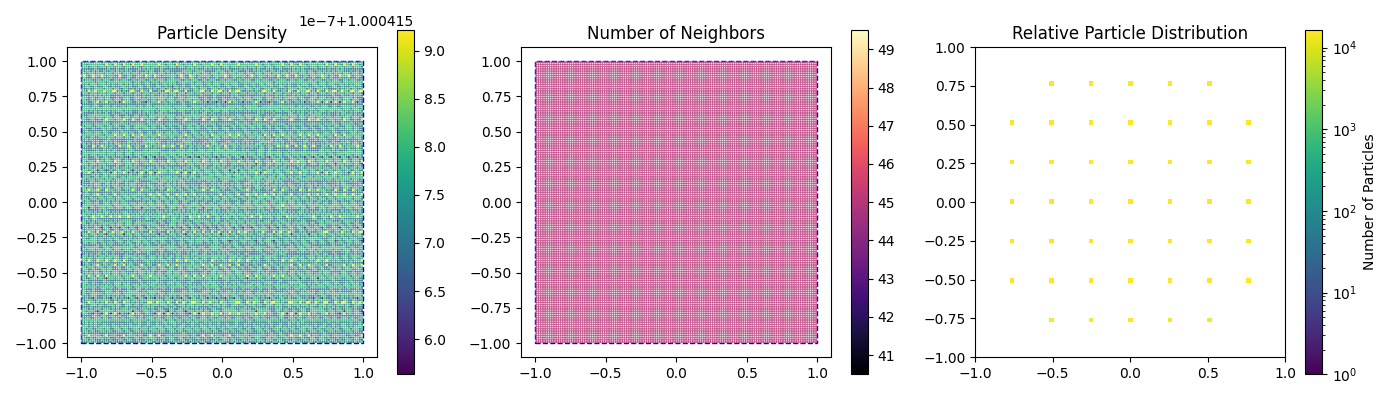

In [3]:
particles, numNeighbors, counter = sampleParticles(nx, scheme=SamplingScheme.regular)
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

visualize(particles, numNeighbors, counter);

In [4]:
from diffSPH.noise import generateOctaveNoise
from scipy.interpolate import RegularGridInterpolator
import numpy as np

def sampleC(particleState, config):
    positions = getPeriodicPositions(particleState.positions, config['domain'])
    cGrid = torch.ones(positions.shape[0], device = 'cuda') * 0.5

    # xx, yy , noise = generateOctaveNoise(n = nx * 4, dim = 2, octaves = 2, baseFrequency = 1, kind = 'perlin', tileable=True, seed = 12365)

    # cTarget = noise / 2 + 0.5
    # # cGrid = noise / 2 + 0.5

    # # # cTarget = torch.where(yy < 0, 1, 0.5)
    # # # cTarget[:] = 0.5
    # # cTarget = torch.where(torch.sqrt(xx**2 + yy**2) < 0.25, 0, 1)
    # cInterp = RegularGridInterpolator((np.linspace(-1,1,cTarget.shape[0]), np.linspace(-1,1,cTarget.shape[1])), cTarget.numpy())
    # cGrid = torch.tensor(cInterp(particleState.positions.cpu())).to('cuda')

    # cGrid = sampleVoronoi(positions, nx, octaves = 3, baseFrequency = 2, kind = 'perlin', tileable=True, seed = 12365, vmin = 0.5, vmax = 1.0, config=config)

    # cGrid[:] *= 2 - 1 * torch.abs(grid[:,1])

    # cGrid = sampleVoronoiC(positions)
    cGrid[:] = torch.where(torch.logical_or(
        torch.logical_and(positions[:,0] > 0.5, positions[:,1] < 0.5), 
        torch.logical_and(positions[:,0] < -0.5, positions[:,1] < 0.5)), 0., 1)
    # cGrid[:] = torch.where(torch.logical_and(positions[:,0].abs() > 0.125, positions[:,1].abs() < 0.025), 0.0, 1)
    cGrid[:] = 1
    return cGrid

In [5]:
def sampleU(particleState, neighbors, config, uMag = 10):
    positions = getPeriodicPositions(particleState.positions, config['domain'])
    sampled = torch.zeros(positions.shape[0], device = positions.device)

    # numWaves = torch.randint(2, 8, (1,)).item()
    # for _ in range(numWaves):
    #     location = torch.rand(2, device = positions.device) * 2 - 1
    #     amplitude = torch.rand(1, device = positions.device) * 2 - 1
    #     radius = torch.rand(1, device = positions.device) * 0.15 + 0.05

    #     sphereEmitter = lambda points: getSDF('circle')['function'](points, radius)
    #     translated = operatorDict['translate'](sphereEmitter, torch.tensor([location[0],location[1]], device = positions.device))
    #     curSample = amplitude * torch.where(translated(positions) < 0, 1, 0).float()[:,0]
    #     # print(curSample.shape)
    #     sampled += curSample

    # positions = getModPosition(positions_, config)
    # sphereEmitter = lambda points: getSDF('circle')['function'](points, 0.025)
    # translated = operatorDict['translate'](sphereEmitter, torch.tensor([0.0,0.5], device = positions.device))
    # sampled = torch.where(translated(positions) < 0, 1, 0).float()

    # translated = operatorDict['translate'](sphereEmitter, torch.tensor([0.0,-0.5], device = positions.device))
    # sampled -= torch.where(translated(positions) < 0, 1, 0).float()
    # sampled = smoothGrid(gridState, sampled) * 10

    # lineEmitter = operatorDict['translate'](lambda points: getSDF('box')['function'](points, torch.tensor([1.0,0.015], device = positions.device)), torch.tensor([0.0,0.85], device = positions.device))
    # sampled = torch.where(lineEmitter(positions) < 0, 1, 0).float()
    # lineEmitter2 = operatorDict['translate'](lambda points: getSDF('box')['function'](points, torch.tensor([1.0,0.015], device = positions.device)), torch.tensor([0.0,-0.85], device = positions.device))
    # sampled -= torch.where(lineEmitter2(positions) < 0, 1, 0).float()

    sampled = torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,-0.5], device = positions.device))(positions) < 0, 1, 0).float()

    # sampled -= torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,0.5], device = positions.device))(positions) < 0, 1, 0).float()

    
    # sampled = torch.where(translated(positions) < 0, 1, 0).float()

    # sampled = SPHOperation(
    #     particleState,
    #     sampled,
    #     config['kernel'],
    #     neighbors.get('noghost')[0],
    #     neighbors.get('noghost')[1],
    #     Operation.Interpolate,
    #     supportScheme = SupportScheme.Gather)

    # for _ in range(8):
        # sampled = smoothGrid(gridState, sampled)


    sampled = sampled * uMag
    return sampled



# def sampleU(particleState, neighbors, config, uMag = 10):
#     positions = getPeriodicPositions(particleState.positions, config['domain'])
#     sampled = torch.zeros(positions.shape[0], device = positions.device)

#     sampled =torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,-0.5], device = positions.device))(positions) < 0, 1, 0).float()
#     sampled = sampled - torch.where(operatorDict['translate'](lambda points: getSDF('circle')['function'](points, 0.125), torch.tensor([0.0,0.5], device = positions.device))(positions) < 0, 1, 0).float()

#     sampled = sampled * uMag
#     return sampled


In [6]:
from damping import *

In [7]:
u, v = torch.zeros(nx**2, device = 'cuda'), torch.zeros(nx**2, device = 'cuda')

cGrid = sampleC(particleState, config)
# For PERIODIC domains: use uniform global damping instead of edge damping
# dampGrid = sampleDamping(particleState, config, 
#                         periodic_mode=True,     # Enable periodic mode
#                         global_damping=0.05)    # Weak uniform damping (adjust 0.01-0.1)
# For NON-PERIODIC domains: uncomment below and comment above
# dampGrid = sampleDamping(particleState, config, 
#                         dampingWidth=0.15, dampingStrength=8.0, profile='cosine')

# noDamping = 0
# globalDamping = 1
# globalDamping_strong = 2
# borderDamping = 3
# borderDamping_strong = 4
# randomDamping = 5
dampGrid = createDampingProfile(particleState, config, DampingProfiles.randomDamping) 

u = sampleU(particleState, neighbors, config, uMag = 10)

state = WaveEquationState(
    u = u,
    v = v,
    c = cGrid,

    damping = dampGrid)

In [8]:
plotInterval = 10
# state = copy.deepcopy(initialState)
nIter = 1000
dt = 0.0025
t = 0.0

In [9]:
from sample import smoothState
from util import plotState
export = False
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
integrator = getIntegrator(config['integrationScheme'])

u, v = torch.zeros(nx**2, device = 'cuda'), torch.zeros(nx**2, device = 'cuda')
cGrid = sampleC(particleState, config)

# noDamping = 0
# globalDamping = 1
# globalDamping_strong = 2
# borderDamping = 3
# borderDamping_strong = 4
# randomDamping = 5
dampGrid = createDampingProfile(particleState, config, DampingProfiles.randomDamping) 

u = sampleU(particleState, neighbors, config, uMag = 10)

waveState = WaveEquationState(
    u = u,
    v = v,
    c = cGrid,
    damping = dampGrid
)
smoothedState = smoothState(waveState, particleState, 2, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = smoothedState,
    neighborhood = neighbors.get('noghost'),

    t = t)

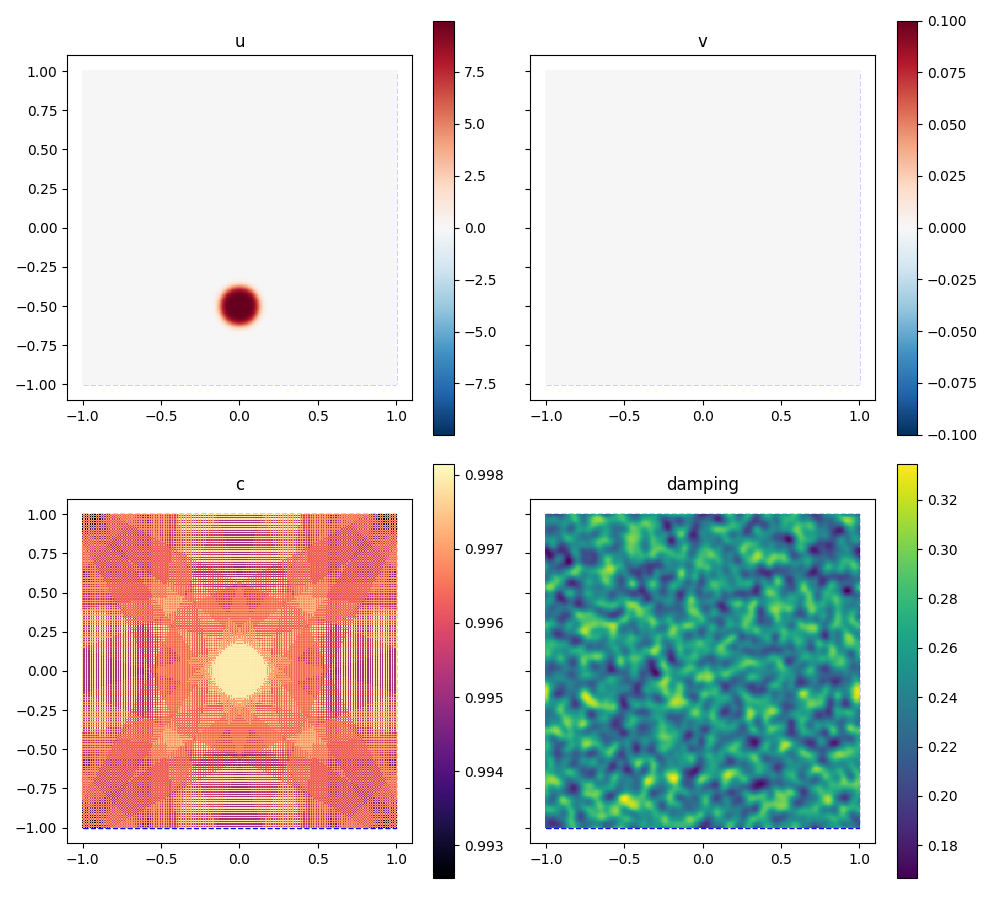

In [10]:
fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    smoothedState,
    config, kernel,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = True)


In [11]:
from simulation import runSimulation
runSimulation(fig, particleState, uPlot, vPlot, waveSystem, waveSystemFunction, integrator, nx, dt, nIter, kernel, config, export, plotInterval = 50, exportImages = False)

  0%|          | 0/1000 [00:00<?, ?it/s]